# SIREN Calibration

True data generated with `siren_params.npz`. Training starts from `siren_params2.npz`.
Physical scalar parameters (`scatter_length`, etc.) are **frozen** — only `siren_params` is optimised.

In [3]:
import sys
sys.path.append('../')

import jax
import jax.numpy as jnp
from jax import value_and_grad, jit
import optax
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

from lucid.simulation import setup_event_simulator

from lucid.geometry import generate_detector

from lucid.losses import WC_smooth_loss
from lucid.detector_params import (
    DetectorParams, laser_source, isotropic_source,
    normalize_params, denormalize_params, default_bounds,
    make_optimization_mask,
)
from lucid.AbsorptionSIREN.siren_loader import setup_siren, make_absorption_fn
from lucid.AbsorptionSIREN.siren_model import build_model, init_model

In [4]:
default_json_filename = '../config/SK_geom_config.json'
detector   = generate_detector(default_json_filename)
detector_points = jnp.array(detector.all_points)
NUM_DETECTORS   = len(detector_points)

# ── Simulation budget ──────────────────────────────────────────────────────
Nphot      = 50000      # photons for training forward pass
K          = 8
Nphot_True = 1500000   # photons for true-data generation
K_True     = 12

# ── Load SIREN models ──────────────────────────────────────────────────────
# true_siren_params  → used to generate the reference dataset
# init_siren_params  → starting point for optimisation
siren_model,      true_siren_params = setup_siren('../lucid/AbsorptionSIREN/true_siren_params.npz')
_siren_model_init = build_model()
init_siren_params    = init_model(_siren_model_init, jax.random.PRNGKey(0))
#_siren_model_init, init_siren_params = setup_siren('../lucid/AbsorptionSIREN/siren_params2.npz')

# ── Fixed physical detector params (same for true data and training) ───────
PHYSICAL_PARAMS = dict(
    scatter_length        = jnp.array(50.0),
    wall_reflection_rate  = jnp.array(0.2),
    sensor_reflection_rate= jnp.array(0.2),
    absorption_length     = jnp.array(50.0),
    qe                    = jnp.array(0.065),
    qe_corrections        = jnp.ones(NUM_DETECTORS),
)

TRUE_PARAMS = DetectorParams(**PHYSICAL_PARAMS, siren_params=true_siren_params)

# ── Optimiser hyperparams ──────────────────────────────────────────────────
ADAM_LR         = 5e-5
ADAM_ITERATIONS = 10
WARMUP_FRACTION = 0.1
TRAINABLE_FIELDS = {'siren_params'}          # freeze everything else

# ── Source ─────────────────────────────────────────────────────────────────
source = isotropic_source(position=[0.0, 0.0, 0.0], intensity=100_000_000) #detector.H / 2 - 0.1 f

COLORS = ['#0077BB', '#EE7733', '#009988', '#EE3377']

[siren_loader] Parameters loaded from ../lucid/AbsorptionSIREN/true_siren_params.npz


In [5]:
# Simulator used during training (differentiable w.r.t. siren_params)
simulate_event = setup_event_simulator(
    default_json_filename, Nphot, temperature=None, K=K,
    is_data=False, is_calibration=True, hit_mode='aggregated',
    wavelength_mode=False,
    siren_params=true_siren_params,
)

# High-stats simulator to generate the reference dataset
simulate_data = setup_event_simulator(
    default_json_filename, Nphot_True, temperature=None, K=K_True,
    is_data=False, is_calibration=True, hit_mode='aggregated',
    default_detector_params=TRUE_PARAMS,
    wavelength_mode=False,
    siren_params=true_siren_params,
)

In [6]:
key = jax.random.PRNGKey(42)
key_source, key_data = jax.random.split(key, 2)

print("Generating true data (this can take a while)...")
true_data = jax.lax.stop_gradient(simulate_data(source, key_data))
print(f"Active sensors : {int(jnp.sum(true_data[0] > 0))} / {NUM_DETECTORS}")

Generating true data (this can take a while)...
Active sensors : 11096 / 11096


In [7]:
# ── Finite-difference check — no JAX grad involved ────────────────────────
# If diff != 0 the loss depends on siren_params → gradient flow exists.
print("Finite-difference gradient check...")

eps = 1e-3
init_dp = DetectorParams(**PHYSICAL_PARAMS, siren_params=init_siren_params)

def _loss(dp):
    sim = simulate_event(source, dp, key_source)
    return float(WC_smooth_loss(detector_points, *true_data, *sim,
                                lambda_poisson=1.0, lambda_time=0.0, tau=1.0))

# Find the first 2-D leaf (weight matrix, not bias vector)
all_leaves = jax.tree.leaves(init_siren_params)
leaf_idx   = next(i for i, l in enumerate(all_leaves) if l.ndim >= 2)
target_leaf = all_leaves[leaf_idx]
perturb     = jnp.zeros_like(target_leaf).at[0, 0].set(eps)

def _replace_leaf(sp, idx, delta):
    leaves, treedef = jax.tree_util.tree_flatten(sp)
    leaves[idx] = leaves[idx] + delta
    return treedef.unflatten(leaves)

dp_plus  = init_dp._replace(siren_params=_replace_leaf(init_siren_params, leaf_idx,  perturb))
dp_minus = init_dp._replace(siren_params=_replace_leaf(init_siren_params, leaf_idx, -perturb))

loss_plus  = _loss(dp_plus)
loss_minus = _loss(dp_minus)

print(f"  loss(+eps) = {loss_plus:.6f}")
print(f"  loss(-eps) = {loss_minus:.6f}")
print(f"  diff       = {loss_plus - loss_minus:.6f}  →  gradient flows: {abs(loss_plus - loss_minus) > 0}")


Finite-difference gradient check...
  loss(+eps) = 0.018063
  loss(-eps) = 0.018063
  diff       = 0.000000  →  gradient flows: True


In [8]:
# Normalisation bounds (only used for physical fields; siren_params pass through unchanged)
bounds_min, bounds_max = default_bounds(NUM_DETECTORS)
bounds_min = bounds_min._replace(
    scatter_length        = jnp.array(5.0),
    wall_reflection_rate  = jnp.array(0.05),
    sensor_reflection_rate= jnp.array(0.05),
    absorption_length     = jnp.array(10.0),
)

@jit
def loss_fn(detector_params):
    sim = simulate_event(source, detector_params, key_source)
    return WC_smooth_loss(
        detector_points, *true_data, *sim,
        lambda_poisson=1.0, lambda_time=0.0, tau=1.0
    )

@jit
def step_fn(params):
    # params here are already denormalised for siren (siren_params not normalised)
    return value_and_grad(
        lambda p: loss_fn(denormalize_params(p, bounds_min, bounds_max))
    )(params)

In [9]:
ADAM_LR         = 5e-4
ADAM_ITERATIONS = 500
WARMUP_FRACTION = 0.1
print("\n=== SIREN Calibration ===")
print(f"  Training  : siren_params2.npz")
print(f"  True data : siren_params.npz")
print(f"  Iterations: {ADAM_ITERATIONS}  |  LR: {ADAM_LR}  |  N_phot: {Nphot:,}  |  K: {K}")

# Starting point: fixed physical params + init siren weights
init_detector_params = DetectorParams(**PHYSICAL_PARAMS, siren_params=init_siren_params)
params = normalize_params(init_detector_params, bounds_min, bounds_max)

# Optimizer: Adam only on siren_params, zero update elsewhere
mask        = make_optimization_mask(params, TRAINABLE_FIELDS)
param_labels = jax.tree.map(lambda m: 'train' if m else 'freeze', mask)

warmup_steps = int(WARMUP_FRACTION * ADAM_ITERATIONS)
lr_schedule  = optax.warmup_constant_schedule(
    init_value=0.0, peak_value=ADAM_LR, warmup_steps=warmup_steps
)
base_optimizer = optax.multi_transform({
    'train' : optax.adam(learning_rate=lr_schedule, b1=0.9, b2=0.999),
    'freeze': optax.set_to_zero(),
}, param_labels)
optimizer = optax.chain(optax.clip_by_global_norm(1.0), base_optimizer)
opt_state = optimizer.init(params)

losses          = []
siren_l2_hist   = []   # L2 distance between current and true siren weights
gradient_norms  = []

true_leaves = jax.tree.leaves(true_siren_params)

start_time = time.time()
pbar = tqdm(range(ADAM_ITERATIONS))

for iteration in pbar:
    loss_val, grad_val = step_fn(params)

    if not jnp.isfinite(loss_val):
        print(f"  [it {iteration}] LOSS NaN/Inf — stopping")
        break

    updates, opt_state = optimizer.update(grad_val, opt_state)
    params = optax.apply_updates(params, updates)

    # Track L2 distance between current siren weights and the true ones
    curr_leaves = jax.tree.leaves(
        denormalize_params(params, bounds_min, bounds_max).siren_params
    )
    siren_l2 = float(jnp.sqrt(sum(
        jnp.sum((c - t) ** 2)
        for c, t in zip(curr_leaves, true_leaves)
    )))

    siren_grad_leaves = jax.tree.leaves(grad_val.siren_params)
    siren_grad_norm   = float(jnp.sqrt(sum(jnp.sum(g**2) for g in siren_grad_leaves
                                           if jnp.all(jnp.isfinite(g)))))

    losses.append(float(loss_val))
    siren_l2_hist.append(siren_l2)
    gradient_norms.append(siren_grad_norm)

    pbar.set_postfix(loss=f"{float(loss_val):.4f}", siren_l2=f"{siren_l2:.4f}", grad=f"{siren_grad_norm:.2e}")

runtime = time.time() - start_time
print(f"\nDone in {runtime:.1f}s  |  final loss={losses[-1]:.6f}  |  final siren_l2={siren_l2_hist[-1]:.6f}")


=== SIREN Calibration ===
  Training  : siren_params2.npz
  True data : siren_params.npz
  Iterations: 500  |  LR: 0.0005  |  N_phot: 50,000  |  K: 8


100%|███████████████████████████████████| 500/500 [11:13<00:00,  1.35s/it, grad=2.72e-02, loss=0.0168, siren_l2=15.2378]


Done in 673.2s  |  final loss=0.016766  |  final siren_l2=15.237761


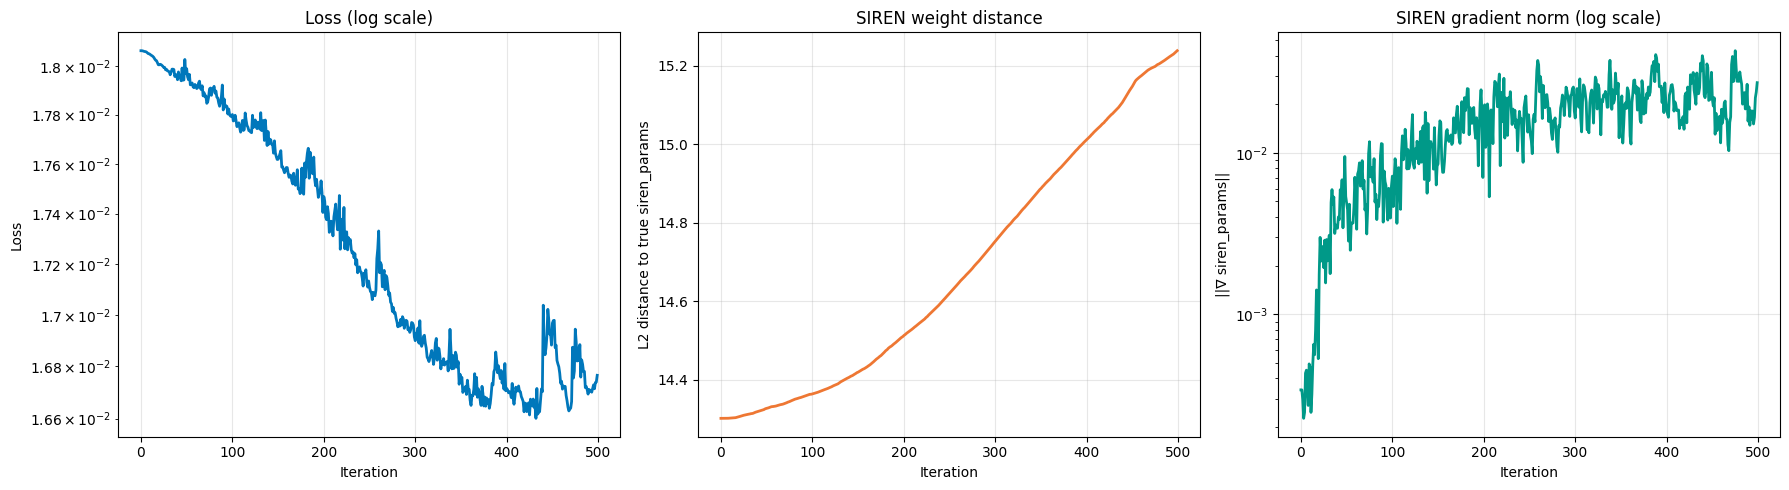

In [10]:
import os
os.makedirs('figures', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(losses, color=COLORS[0], linewidth=2)
axes[0].set_yscale('log')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss (log scale)')
axes[0].grid(True, alpha=0.3)

# SIREN L2 distance to true weights
axes[1].plot(siren_l2_hist, color=COLORS[1], linewidth=2)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('L2 distance to true siren_params')
axes[1].set_title('SIREN weight distance')
axes[1].grid(True, alpha=0.3)

# Gradient norms
axes[2].plot(gradient_norms, color=COLORS[2], linewidth=2)
axes[2].set_yscale('log')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('||∇ siren_params||')
axes[2].set_title('SIREN gradient norm (log scale)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/siren_calibration.png', dpi=300, bbox_inches='tight')
plt.show()

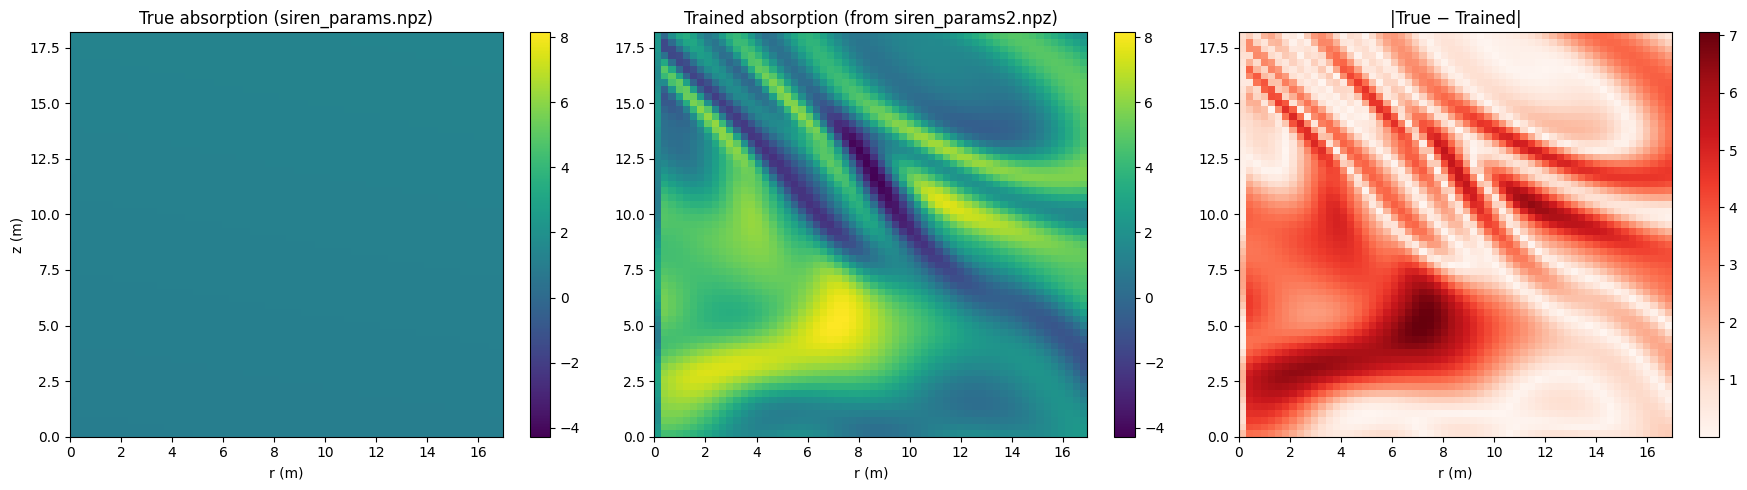

Max abs error : 7.0533


In [11]:
# Compare absorption maps: true vs trained
final_params    = denormalize_params(params, bounds_min, bounds_max)
absorption_fn   = make_absorption_fn(siren_model, R=detector.r, H=detector.H)

# Sample a 2-D grid in the (r, z) plane
r_vals = jnp.linspace(0, detector.r,   60)
z_vals = jnp.linspace(0, detector.H/2, 60)
RR, ZZ = jnp.meshgrid(r_vals, z_vals)
xyz_grid = jnp.stack([RR.ravel(), jnp.zeros_like(RR.ravel()), ZZ.ravel()], axis=-1)

abs_true    = absorption_fn(xyz_grid, true_siren_params ).reshape(60, 60)
abs_trained = absorption_fn(xyz_grid, final_params.siren_params).reshape(60, 60)

vmin = float(jnp.minimum(abs_true.min(), abs_trained.min()))
vmax = float(jnp.maximum(abs_true.max(), abs_trained.max()))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(abs_true,    origin='lower', aspect='auto',
                     extent=[0, float(detector.r), 0, float(detector.H/2)],
                     vmin=vmin, vmax=vmax, cmap='viridis')
axes[0].set_title('True absorption (siren_params.npz)')
axes[0].set_xlabel('r (m)'); axes[0].set_ylabel('z (m)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(abs_trained, origin='lower', aspect='auto',
                     extent=[0, float(detector.r), 0, float(detector.H/2)],
                     vmin=vmin, vmax=vmax, cmap='viridis')
axes[1].set_title('Trained absorption (from siren_params2.npz)')
axes[1].set_xlabel('r (m)')
plt.colorbar(im1, ax=axes[1])

diff = jnp.abs(abs_true - abs_trained)
im2 = axes[2].imshow(diff, origin='lower', aspect='auto',
                     extent=[0, float(detector.r), 0, float(detector.H/2)],
                     cmap='Reds')
axes[2].set_title('|True − Trained|')
axes[2].set_xlabel('r (m)')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.savefig('figures/siren_absorption_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Max abs error : {float(diff.max()):.4f}")

[4.922268]


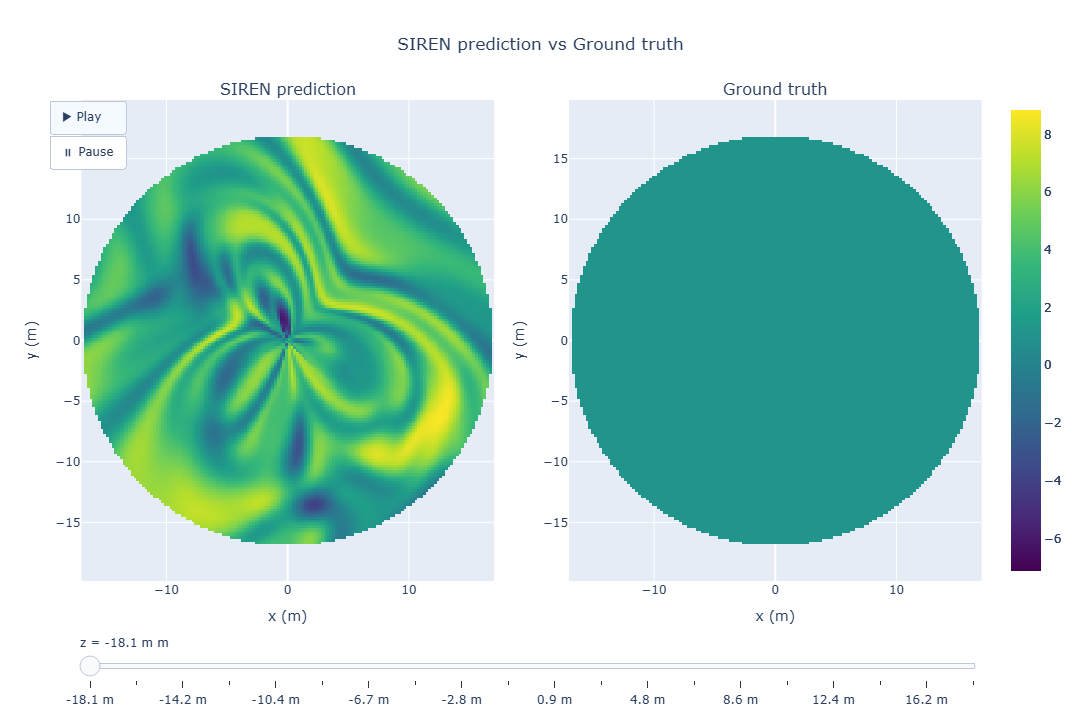

In [15]:
from lucid.AbsorptionSIREN.visualize_3d import plot_interactive_comparison
print(absorption_fn(jnp.array([[16.0, 0.0, 17.0]]), final_params.siren_params))
plot_interactive_comparison(lambda x: absorption_fn(x, final_params.siren_params), lambda x: absorption_fn(x, true_siren_params))